# 1.1 Load and inspect a single TCX file

Before processing all activities, load one TCX file to verify that:

- the parser correctly extracts distance, heart rate, and cadence  
- speed and pace are computed correctly  
- the time index is continuous and sorted  
- no values are missing or obviously wrong

`df.head()` shows the first few seconds of the run, and  
`.describe()` summarises the main time-series variables to check their ranges and ensure the raw data looks correct before extracting features.

In [16]:
from parse_tcx import parse_tcx

df = parse_tcx("../data/raw/activity_20401950071.tcx")
print(df.head())
print(df[["speed_mps", "pace_s_per_km", "hr", "cadence"]].describe())

                                               time    hr  cadence  \
time                                                                 
2025-09-16 10:11:45+00:00 2025-09-16 10:11:45+00:00  83.0     58.0   
2025-09-16 10:11:46+00:00 2025-09-16 10:11:46+00:00  84.0     58.0   
2025-09-16 10:11:47+00:00 2025-09-16 10:11:47+00:00  84.0     58.0   
2025-09-16 10:11:48+00:00 2025-09-16 10:11:48+00:00  85.0     58.0   
2025-09-16 10:11:49+00:00 2025-09-16 10:11:49+00:00  86.0     58.0   

                           distance_m  speed_mps     elev_m  elapsed_s  \
time                                                                     
2025-09-16 10:11:45+00:00        2.91      0.504  21.000000        0.0   
2025-09-16 10:11:46+00:00        4.85      1.372  21.000000        1.0   
2025-09-16 10:11:47+00:00        4.97      1.064  21.000000        2.0   
2025-09-16 10:11:48+00:00        5.99      0.942  20.799999        3.0   
2025-09-16 10:11:49+00:00        6.94      0.942  20.600000      

# 1.2 Resample run to 1 Hz and compute features for one activity

Take the raw TCX data for a single run and pass it through the feature pipeline:

1. `parse_tcx(...)` loads the original time series (distance, HR, cadence, speed, pace).
2. `resample_to_1s(df_raw)` converts it to a clean 1-second grid and recomputes pace/speed.
3. `compute_early_late_features(df_1s)` splits the run into early and late segments (first/last 30%) and calculates:
   - mean, standard deviation, and coefficient of variation for pace, HR, and cadence  
   - drift metrics (late mean – early mean).
4. `compute_surge_features(df_1s)` counts how many “pace surges” (large speed changes) occur over the whole run and specifically in the late segment.

The output (`early_late_feats`, `surge_feats`) is a compact feature vector describing how pacing, HR, and cadence behave and how erratic the pacing becomes as fatigue builds in this single run.

In [17]:
from pathlib import Path
from parse_tcx import parse_tcx
from features import (
    resample_to_1s,
    compute_early_late_features,
    compute_surge_features,
)

fp = Path("../data/raw/activity_20401950071.tcx")  # or whichever file
df_raw = parse_tcx(fp)
df_1s = resample_to_1s(df_raw)

early_late_feats = compute_early_late_features(df_1s)
surge_feats = compute_surge_features(df_1s)

early_late_feats, surge_feats

/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:22: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()


({'early_hr_mean': 145.19573901464713,
  'late_hr_mean': 152.30093209054593,
  'hr_mean_drift': 7.1051930758987965,
  'early_pace_s_per_km_mean': 348.71213256320686,
  'late_pace_s_per_km_mean': 360.1688437836151,
  'pace_s_per_km_mean_drift': 11.456711220408238,
  'pace_cv_early': 0.22374874576421938,
  'pace_cv_late': 0.029145522485091866,
  'pace_cv_ratio': 0.1302600485448292,
  'cadence_cv_early': 0.11900035204605905,
  'cadence_cv_late': 0.07398391224621353,
  'cadence_cv_ratio': 0.6217117090340882,
  'flat_hr_mean_drift': 5.9227528089887755,
  'flat_pace_mean_drift': 6.5606007694021855},
 {'surges_all_10s_8pct': 105, 'surges_late_10s_8pct': 12})

# 1.3 Build the full feature table for all TCX files

Loop through every TCX file in `data/raw` and run the complete feature extraction pipeline:

1. **Load raw file** → `parse_tcx(fp)`  
2. **Resample to 1 Hz** → `resample_to_1s(df_raw)`  
3. **Compute early/late metrics** → pacing, HR, cadence drift and CV  
4. **Compute surge metrics** → total surges and late-segment surges  
5. Store all outputs in a dictionary representing one run  
6. Append to `all_runs`

After processing all activities, convert the list of dictionaries into a DataFrame:

- Each row = one run  
- Columns = all early/late stats and surge counts  
- `features_df.describe()` provides a quick check of value ranges and missing data

In [18]:
import pandas as pd
from pathlib import Path
from parse_tcx import parse_tcx
from features import (
    resample_to_1s,
    compute_early_late_features,
    compute_surge_features,
    compute_terrain_features,
)

data_dir = Path("../data/raw")
files = list(data_dir.glob("*.tcx"))
print("Found files:", len(files))

all_runs = []

for fp in files:
    # 1. load raw TCX
    df_raw = parse_tcx(fp)

    # 2. resample to 1 Hz
    df_1s = resample_to_1s(df_raw)

    # basic metadata for this run
    run_start = df_raw["time"].iloc[0]

    feats = {
        "file": fp.name,
        "start_time": run_start,
    }

    # 3. early/late features (pace/HR/cadence drift + CVs, etc.)
    feats.update(compute_early_late_features(df_1s))

    # 4. surge metrics
    feats.update(compute_surge_features(df_1s))

    # 5. terrain / hills / elevation-based metrics (incl. flat-only drifts)
    feats.update(compute_terrain_features(df_1s))

    all_runs.append(feats)

# build final feature table
features_df = (
    pd.DataFrame(all_runs)
    .sort_values("start_time")
    .reset_index(drop=True)
)

print("Feature table shape:", features_df.shape)
display(features_df.head())

# quick check of ranges and missing data
features_df.describe(include="all")


Found files: 20


/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:22: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:22: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:22: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:22: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:22: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = d

Feature table shape: (20, 27)


/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:22: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()


,file,start_time,early_hr_mean,late_hr_mean,hr_mean_drift,early_pace_s_per_km_mean,late_pace_s_per_km_mean,pace_s_per_km_mean_drift,pace_cv_early,pace_cv_late,...,surges_late_10s_8pct,total_elev_gain_m,total_distance_km,elev_gain_per_km,pct_time_uphill,pct_time_flat,pct_time_downhill,mean_grade_uphill_pct,mean_vspeed_uphill_mh,is_hilly_run
0,activity_20401950071.tcx,2025-09-16 10:11:45+00:00,145.195739,152.300932,7.105193,348.712133,360.168844,11.456711,0.223749,0.029146,...,12,122.400009,7.00607,17.470566,21.631347,56.937225,21.431427,8.057957,809.168262,False
1,activity_20411248791.tcx,2025-09-17 06:28:58+00:00,153.056675,175.006297,21.949622,343.230323,321.152027,-22.078296,0.070032,0.126631,...,42,103.400003,8.00687,12.913910,18.095958,64.488100,17.415943,7.307536,774.112760,False
2,activity_20432446314.tcx,2025-09-19 07:13:58+00:00,160.698157,159.669355,-1.028802,355.274019,356.782885,1.508866,0.206449,0.142299,...,44,91.999994,8.01254,11.482001,14.557400,71.161826,14.280775,7.657137,783.277860,False
3,activity_20535336288.tcx,2025-09-29 11:35:15+00:00,151.807692,168.937666,17.129973,367.206760,355.725325,-11.481434,0.129237,0.166619,...,192,73.199998,6.66086,10.989572,13.659896,75.308642,11.031462,7.646768,720.000054,False
4,activity_20549513473.tcx,2025-09-30 17:40:09+00:00,168.785582,189.724584,20.939002,431.728184,440.319278,8.591095,1.075420,0.689920,...,152,42.199995,5.75801,7.328920,11.098779,77.358491,11.542730,7.319094,719.999863,False


,file,start_time,early_hr_mean,late_hr_mean,hr_mean_drift,early_pace_s_per_km_mean,late_pace_s_per_km_mean,pace_s_per_km_mean_drift,pace_cv_early,pace_cv_late,...,surges_late_10s_8pct,total_elev_gain_m,total_distance_km,elev_gain_per_km,pct_time_uphill,pct_time_flat,pct_time_downhill,mean_grade_uphill_pct,mean_vspeed_uphill_mh,is_hilly_run
count,20,20,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,19.000000,19.000000,20
unique,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,activity_20401950071.tcx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18
mean,NaN,2025-10-06 15:58:12.799999744+00:00,157.016131,170.931574,13.915443,371.733911,387.805220,16.071308,0.286118,0.296218,...,114.750000,97.799997,7.889352,12.524865,15.603553,69.841241,14.555206,7.868516,780.763781,NaN
min,NaN,2025-09-16 10:11:45+00:00,142.970501,152.300932,-1.028802,254.427168,269.224588,-37.379195,0.053443,0.019062,...,4.000000,0.000000,3.005450,0.000000,0.000000,34.243837,0.000000,5.935343,719.999777,NaN
25%,NaN,2025-10-01 23:06:24+00:00,151.025746,159.503847,8.316806,341.075776,350.688818,-13.452289,0.116485,0.080812,...,43.500000,57.150002,5.615300,9.409103,12.440096,64.347738,10.929347,7.313315,730.264021,NaN
50%,NaN,2025-10-07 01:25:24+00:00,154.044409,169.229142,14.452751,367.946454,382.309332,4.459868,0.183451,0.148804,...,105.000000,96.700001,6.945480,11.703223,14.217945,72.735257,13.093107,8.057957,748.381818,NaN
75%,NaN,2025-10-12 17:20:34.750000128+00:00,163.040607,180.976550,20.447611,398.971210,423.100725,15.107938,0.290165,0.362233,...,167.250000,122.800009,8.189808,13.982790,18.909306,77.177083,17.229420,8.369972,778.695310,NaN
max,NaN,2025-11-01 11:52:58+00:00,179.629238,194.688654,25.279823,482.858631,651.884585,169.025953,1.075420,1.179273,...,266.000000,301.199974,21.113330,32.493719,32.844770,100.000000,32.911392,10.109658,1197.565930,NaN


# 2.1 Building Fatigue Scores (CML & GPV)

This section transforms the raw run-level features into two core fatigue metrics:

### 1. Derived Ratios
We compute three ratios that express how much *variability or instability* increases from the early part of the run to the late part:

- **pace_cv_ratio**  
  = late pace CV / early pace CV  
  → how much pacing variability worsened under fatigue

- **cadence_cv_ratio**  
  = late cadence CV / early cadence CV  
  → whether the runner struggled to maintain a stable rhythm

- **surge_ratio**  
  = late surges / total surges  
  → whether pacing becomes more erratic later in the run

We also clean infinities (e.g., if the early CV was zero).

---

### 2. Z-Scoring (Normalization)
All fatigue-relevant variables are converted to **z-scores within your dataset**, so that:

- 0 = average for your runs  
- +1 = 1 standard deviation above your norm (higher fatigue signal)  
- –1 = 1 standard deviation below your norm (lower fatigue signal)

Z-scored variables:
- hr_mean_drift  
- late_hr_mean  
- pace_mean_drift  
- pace_cv_ratio  
- cadence_cv_ratio  
- surge_ratio

---

### 3. Building Composite Fatigue Metrics

#### **Cardio-Metabolic Load (CML_z)**
A composite score reflecting **systemic/physiological load**, combining:
- heart rate drift (strongest contributor)
- late HR level
- pace drift

High CML_z = your *cardio + muscular system* was taxed heavily.

#### **Gait/Pacing Variability (GPV_z)**
A composite score reflecting **coordination, stability, and pacing control**, combining:
- worsening pace variability
- worsening cadence variability
- more late surges

High GPV_z = pacing and mechanics became more unstable.

---

### 4. What These Two Scores Mean

- **CML_z ↑**  
  → more physiological strain (peripheral fatigue: legs/body limitations)

- **GPV_z ↑**  
  → more instability/noise in pacing (central/regulation fatigue: focus/coordination issues)

These two scores form the foundation of the **four-quadrant fatigue classification**:

| Low GPV | High GPV |
|--------|----------|
| **Low CML → Type D (Fresh)** | **Type B (Regulation-Limited)** |
| **High CML → Type A (Body-Limited)** | **Type C (Global Fatigue)** |

In [19]:
import numpy as np
import pandas as pd

# --- 1. Derived ratios -------------------------------------------------

# From early/late CVs returned by compute_early_late_features
features_df["pace_cv_ratio"] = (
    features_df["pace_cv_late"] / features_df["pace_cv_early"]
)

features_df["cadence_cv_ratio"] = (
    features_df["cadence_cv_late"] / features_df["cadence_cv_early"]
)

features_df["surge_ratio"] = (
    features_df["surges_late_10s_8pct"] / features_df["surges_all_10s_8pct"]
)

# clean up infinities / weird values
for col in ["pace_cv_ratio", "cadence_cv_ratio", "surge_ratio"]:
    features_df[col] = features_df[col].replace([np.inf, -np.inf], np.nan)

# --- 2. Helper to compute z-scores -------------------------------------

def zscore(series: pd.Series) -> pd.Series:
    m = series.mean()
    s = series.std(ddof=0)
    if np.isnan(m) or np.isnan(s) or s == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - m) / s


# ---- FULL-RUN drift z-scores (for CML_full_z) -------------------------

features_df["z_hr_mean_drift_full"] = zscore(features_df["hr_mean_drift"])
features_df["z_late_hr_mean"] = zscore(features_df["late_hr_mean"])
features_df["z_pace_mean_drift_full"] = zscore(
    features_df["pace_s_per_km_mean_drift"]
)

# ---- FLAT-ONLY drift z-scores (for CML_flat_z) ------------------------

features_df["z_hr_mean_drift_flat"] = zscore(features_df["flat_hr_mean_drift"])
features_df["z_pace_mean_drift_flat"] = zscore(
    features_df["flat_pace_mean_drift"]
)

# ---- GPV component z-scores -------------------------------------------

features_df["z_pace_cv_ratio"]    = zscore(features_df["pace_cv_ratio"])
features_df["z_cadence_cv_ratio"] = zscore(features_df["cadence_cv_ratio"])
features_df["z_surge_ratio"]      = zscore(features_df["surge_ratio"])

# --- 3. Composite metrics ----------------------------------------------

# Full CML: uses whole-run drift, including hills
features_df["CML_full_z"] = (
    features_df["z_hr_mean_drift_full"]
    + 0.5 * features_df["z_late_hr_mean"]
    + 0.5 * features_df["z_pace_mean_drift_full"]
)

# Flat-only CML: ignores climbs, only looks at drift on flat terrain
features_df["CML_flat_z"] = (
    features_df["z_hr_mean_drift_flat"]
    + 0.5 * features_df["z_pace_mean_drift_flat"]
)

# Terrain-aware effective CML:
# - If run is hilly and we have flat data → use flat-only CML.
# - Else → fall back to full CML.
features_df["CML_z"] = np.where(
    features_df["is_hilly_run"] & features_df["CML_flat_z"].notna(),
    features_df["CML_flat_z"],
    features_df["CML_full_z"],
)

# GPV unchanged: still based on variability / surges
features_df["GPV_z"] = (
    features_df["z_pace_cv_ratio"]
    + 0.5 * features_df["z_cadence_cv_ratio"]
    + 0.5 * features_df["z_surge_ratio"]
)

# preview
features_df[[
    "file",
    "CML_z", "CML_full_z", "CML_flat_z",
    "GPV_z",
    "is_hilly_run",
    "total_elev_gain_m", "elev_gain_per_km"
]].head()


,file,CML_z,CML_full_z,CML_flat_z,GPV_z,is_hilly_run,total_elev_gain_m,elev_gain_per_km
0,activity_20401950071.tcx,-1.663791,-1.663791,-0.764368,-2.249364,False,122.400009,17.470566
1,activity_20411248791.tcx,0.886189,0.886189,0.472736,1.569776,False,103.400003,12.913910
2,activity_20432446314.tcx,-2.585675,-2.585675,-1.657912,0.394470,False,91.999994,11.482001
3,activity_20535336288.tcx,0.104244,0.104244,0.517318,0.298994,False,73.199998,10.989572
4,activity_20549513473.tcx,1.585724,1.585724,0.635094,-0.704909,False,42.199995,7.328920


# 2.2 Interpreting the CML_z and GPV_z Summary Table

This table shows the statistical distribution (count, mean, std, min, percentiles, max) for:
- **CML_z** (systemic load)
- **GPV_z** (pacing variability)

### What each value represents

- **count**  
  Number of runs that were processed.

- **mean**  
  Should be ~0 because these are z-scores.

- **std**  
  Should be ~1 (by definition of z-score).

- **min / max**  
  The lowest/highest fatigue scores relative to your own dataset.

- **25%, 50%, 75% (quartiles)**  
  Show where the middle of your distribution lies:
  - values above 0 → above-average fatigue signal  
  - values below 0 → lower-than-average fatigue signal

### How to read CML_z

- **High CML_z (positive)**  
  → big HR drift, high late HR, large pace slowdown  
  → “body-limited” or systemic fatigue

- **Low CML_z (negative)**  
  → minimal physical load  
  → fresh / controlled / easy run

### How to read GPV_z

- **High GPV_z (positive)**  
  → unstable pacing/cadence, lots of late surges  
  → “regulation-limited” or unstable coordination/focus

- **Low GPV_z (negative)**  
  → smooth, consistent pacing and rhythm  
  → fresh or controlled mechanics

These two distributions help validate whether your dataset has variance and whether the CML/GPV scores behave as expected.

In [20]:
features_df[["CML_z", "GPV_z"]].describe()


,CML_z,GPV_z
count,20.000000,2.000000e+01
mean,-0.051958,9.992007e-17
std,1.519143,1.666188e+00
min,-2.585675,-2.666576e+00
25%,-1.363732,-1.186984e+00
50%,-0.167852,1.102020e-01
75%,1.185773,9.031238e-01
max,2.472335,4.599896e+00


# 2.3 Interpreting the CML_z and GPV_z Summary Table

Neuro-Tagging (Optional User Self-Report Layer)
This section lets me add manual labels describing how the run felt (“legs heavy”, “felt fine”, “mentally tired”), so the classifier can combine objective data (CML & GPV) with subjective neuro-fatigue signals.
I create a dictionary (neuro_map) mapping a file name → a neuro state.
Then I add a new column neuro_tag to the feature table.
Runs not included in the dictionary stay as "none".
This is optional and can be expanded later as I manually annotate more activities.

In [21]:
# Optional neuro-tagging (manual labels for now)
neuro_map = {
    "activity_20432446314.tcx": "body_limited",
    "activity_20401950071.tcx": "fresh",
    # add more labels here as you annotate runs
}

features_df["neuro_tag"] = features_df["file"].map(neuro_map).fillna("none")

features_df[["file", "neuro_tag"]].head()


,file,neuro_tag
0,activity_20401950071.tcx,fresh
1,activity_20411248791.tcx,none
2,activity_20432446314.tcx,body_limited
3,activity_20535336288.tcx,none
4,activity_20549513473.tcx,none


# 2.4 Applying the classifier (fixing the neuro_tag overlap)

`features_df` already contains a `neuro_tag` column from the manual labelling step.  
When I first joined the classifier outputs back onto `features_df`, the result of
`apply_classifier` also contained a `neuro_tag` column, so Pandas raised:

> `ValueError: columns overlap but no suffix specified`

To fix this, I:
- keep `neuro_tag` only in `features_df`
- **do not** return `neuro_tag` from `apply_classifier`
- compute the extra columns in a separate DataFrame and then join it back.


In [22]:
from classifier import classify_run
import pandas as pd

def apply_classifier(row: pd.Series) -> pd.Series:
    result = classify_run(
        cml_z=row["CML_z"],
        gpv_z=row["GPV_z"],
        neuro_tag=row.get("neuro_tag", "none"),
    )
    return pd.Series({
        "base_label": result["base_label"],
        "final_label": result["final_label"],
        "base_code": result["base_code"],
        "final_code": result["final_code"],
        "CML_adj": result["CML_adj"],
        "GPV_adj": result["GPV_adj"],
        "pattern_reasons": result["reasons"],
    })

# run classifier for each row → separate DataFrame
classified_extra = features_df.apply(apply_classifier, axis=1)

# join back to original features_df (no overlapping column names now)
classified_df = features_df.join(classified_extra)

# show activity + start time + key outputs
classified_df[[
    "file",
    "start_time",
    "final_label",
    "neuro_tag",
    "CML_z",
    "GPV_z",
    "CML_adj",
    "GPV_adj",
    "pattern_reasons",
]]


,file,start_time,final_label,neuro_tag,CML_z,GPV_z,CML_adj,GPV_adj,pattern_reasons
0,activity_20401950071.tcx,2025-09-16 10:11:45+00:00,Type D — Fresh / controlled,fresh,-1.663791,-2.249364,-2.363791,-2.949364,"objective CML_z=-1.66, GPV_z=-2.25 → Type D — ..."
1,activity_20411248791.tcx,2025-09-17 06:28:58+00:00,Type C — Global fatigue,none,0.886189,1.569776,0.886189,1.569776,"objective CML_z=0.89, GPV_z=1.57 → Type C — Gl..."
2,activity_20432446314.tcx,2025-09-19 07:13:58+00:00,Mixed / normal,body_limited,-2.585675,0.394470,-1.885675,0.394470,"objective CML_z=-2.59, GPV_z=0.39 → Mixed / no..."
3,activity_20535336288.tcx,2025-09-29 11:35:15+00:00,Mixed / normal,none,0.104244,0.298994,0.104244,0.298994,"objective CML_z=0.10, GPV_z=0.30 → Mixed / normal"
4,activity_20549513473.tcx,2025-09-30 17:40:09+00:00,Type A — Body-limited,none,1.585724,-0.704909,1.585724,-0.704909,"objective CML_z=1.59, GPV_z=-0.70 → Type A — B..."
5,activity_20566587122.tcx,2025-10-02 08:55:09+00:00,Mixed / normal,none,-2.112757,0.164727,-2.112757,0.164727,"objective CML_z=-2.11, GPV_z=0.16 → Mixed / no..."
6,activity_20579970564.tcx,2025-10-03 17:42:48+00:00,Type C — Global fatigue,none,1.695929,4.599896,1.695929,4.599896,"objective CML_z=1.70, GPV_z=4.60 → Type C — Gl..."
7,activity_20584569891.tcx,2025-10-04 09:15:01+00:00,Type D — Fresh / controlled,none,-1.671899,-2.666576,-1.671899,-2.666576,"objective CML_z=-1.67, GPV_z=-2.67 → Type D — ..."
8,activity_20595800285.tcx,2025-10-05 10:29:40+00:00,Type D — Fresh / controlled,none,-0.510605,-1.759780,-0.510605,-1.759780,"objective CML_z=-0.51, GPV_z=-1.76 → Type D — ..."
9,activity_20603961785.tcx,2025-10-06 09:13:25+00:00,Mixed / normal,none,-0.431135,0.230201,-0.431135,0.230201,"objective CML_z=-0.43, GPV_z=0.23 → Mixed / no..."


# 2.5 Visualising the CML × GPV fatigue map

This scatter plot shows each run as a point in the CML_z × GPV_z plane.

- x-axis: CML_z (systemic load)
- y-axis: GPV_z (pacing variability)
- vertical/horizontal lines at 0 show "average" levels.

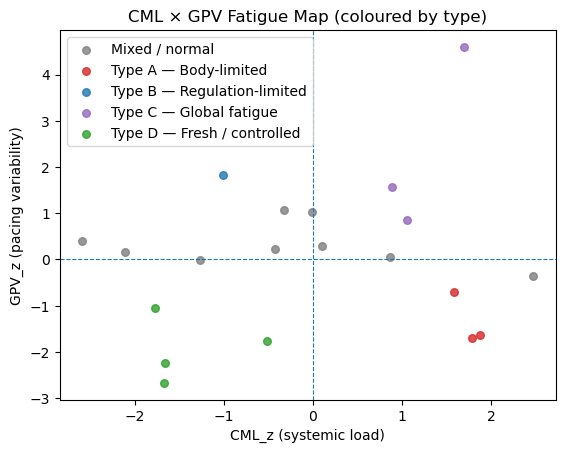

In [23]:
import matplotlib.pyplot as plt
type_colors = {
    "Type A — Body-limited": "tab:red",
    "Type B — Regulation-limited": "tab:blue",
    "Type C — Global fatigue": "tab:purple",
    "Type D — Fresh / controlled": "tab:green",
    "Mixed / normal": "tab:gray",
}

plt.figure()
for label, group in classified_df.groupby("final_label"):
    plt.scatter(
        group["CML_z"],
        group["GPV_z"],
        label=label,
        s=30,
        alpha=0.8,
        c=type_colors.get(label, "tab:gray"),
    )

plt.axvline(0, linestyle="--", linewidth=0.8)
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.xlabel("CML_z (systemic load)")
plt.ylabel("GPV_z (pacing variability)")
plt.title("CML × GPV Fatigue Map (coloured by type)")
plt.legend()
plt.show()


# 2.6 Distribution of fatigue types

In [24]:
classified_df["final_label"].value_counts()

final_label
Mixed / normal                 9
Type D — Fresh / controlled    4
Type C — Global fatigue        3
Type A — Body-limited          3
Type B — Regulation-limited    1
Name: count, dtype: int64

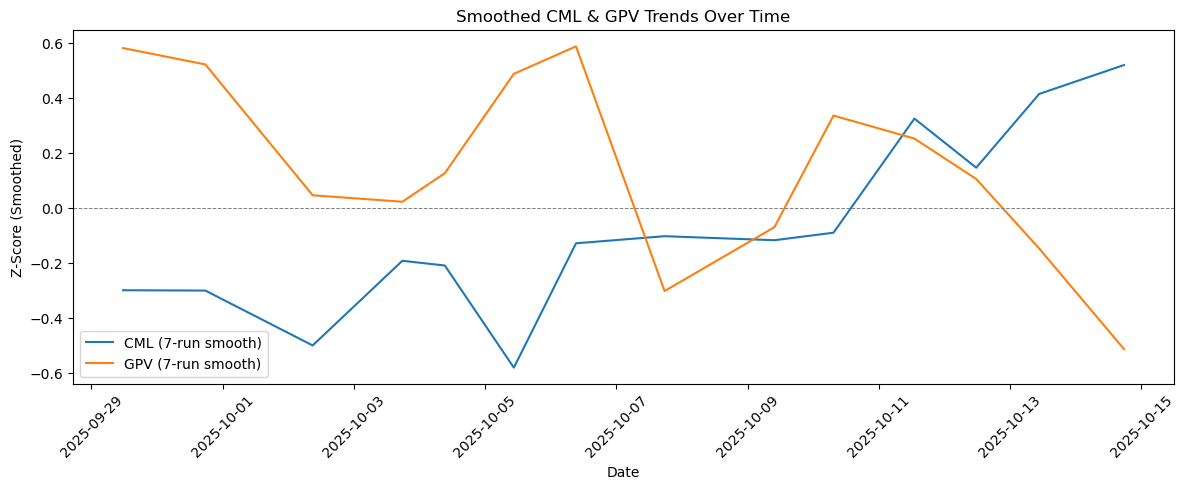

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

classified_df["start_time"] = pd.to_datetime(classified_df["start_time"])
plot_df = classified_df.sort_values("start_time").reset_index(drop=True)

# rolling 7-run smoothing
plot_df["CML_smooth"] = plot_df["CML_z"].rolling(7, center=True).mean()
plot_df["GPV_smooth"] = plot_df["GPV_z"].rolling(7, center=True).mean()

plt.figure(figsize=(12, 5))

plt.plot(plot_df["start_time"], plot_df["CML_smooth"],
         label="CML (7-run smooth)", color="tab:blue")

plt.plot(plot_df["start_time"], plot_df["GPV_smooth"],
         label="GPV (7-run smooth)", color="tab:orange")

plt.axhline(0, color="gray", linestyle="--", linewidth=0.7)
plt.xlabel("Date")
plt.ylabel("Z-Score (Smoothed)")
plt.title("Smoothed CML & GPV Trends Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
# ensure start_time is datetime
classified_df["start_time"] = pd.to_datetime(classified_df["start_time"])

# date-only version
classified_df["date"] = classified_df["start_time"].dt.date

# sort by time
classified_df = classified_df.sort_values("start_time").reset_index(drop=True)

classified_df[["file", "start_time", "date", "final_label"]].head()


,file,start_time,date,final_label
0,activity_20401950071.tcx,2025-09-16 10:11:45+00:00,2025-09-16,Type D — Fresh / controlled
1,activity_20411248791.tcx,2025-09-17 06:28:58+00:00,2025-09-17,Type C — Global fatigue
2,activity_20432446314.tcx,2025-09-19 07:13:58+00:00,2025-09-19,Mixed / normal
3,activity_20535336288.tcx,2025-09-29 11:35:15+00:00,2025-09-29,Mixed / normal
4,activity_20549513473.tcx,2025-09-30 17:40:09+00:00,2025-09-30,Type A — Body-limited


In [14]:
import numpy as np
import pandas as pd

# --- helper: exponential moving average like TrainingPeaks ---
def ewma(series, halflife_days):
    # decay factor: exp(-ln(2) / halflife)
    alpha = 1 - np.exp(np.log(0.5) / halflife_days)
    return series.ewm(alpha=alpha, adjust=False).mean()

# ensure sorted by time
classified_df = classified_df.sort_values("start_time").reset_index(drop=True)

# --- 1. Create daily time series ---
# Some days have multiple runs → take mean of CML, GPV that day
daily = (
    classified_df.groupby(classified_df["start_time"].dt.date)
    [["CML_z", "GPV_z"]]
    .mean()
    .rename_axis("date")
)

# convert index to timestamp
daily.index = pd.to_datetime(daily.index)

# fill all days between first & last run
all_days = pd.date_range(start=daily.index.min(), end=daily.index.max(), freq="D")
daily = daily.reindex(all_days).fillna(0.0)   # no run = 0 load

# --- 2. Compute ATL (7-day) and CTL (42-day) ---
daily["CML_ATL"] = ewma(daily["CML_z"], halflife_days=7)
daily["CML_CTL"] = ewma(daily["CML_z"], halflife_days=42)
daily["CML_TSB"] = daily["CML_CTL"] - daily["CML_ATL"]

daily["GPV_ATL"] = ewma(daily["GPV_z"], halflife_days=7)
daily["GPV_CTL"] = ewma(daily["GPV_z"], halflife_days=42)
daily["GPV_TSB"] = daily["GPV_CTL"] - daily["GPV_ATL"]

daily.tail()


,CML_z,GPV_z,CML_ATL,CML_CTL,CML_TSB,GPV_ATL,GPV_CTL,GPV_TSB
2025-10-28,0.00000,0.000000,0.003292,-0.837916,-0.841208,-0.014509,-1.086414,-1.071905
2025-10-29,0.00000,0.000000,0.002982,-0.824201,-0.827183,-0.013141,-1.068632,-1.055490
2025-10-30,0.00000,0.000000,0.002701,-0.810710,-0.813411,-0.011902,-1.051140,-1.039238
2025-10-31,0.00000,0.000000,0.002446,-0.797440,-0.799886,-0.010780,-1.033935,-1.023155
2025-11-01,1.78848,-1.699476,0.170827,-0.755114,-0.925941,-0.169984,-1.044829,-0.874844


# How to Interpret Load Dashboard
CML curves = body / metabolic fatigue
ATL spikes → heavy running load
CTL rises → long-term fitness improving
TSB negative → physically tired
TSB positive → recovered
GPV curves = neuromuscular / coordination / mental regulation fatigue
ATL spikes after messy rhythm runs
CTL increases during periods of consistent instability
TSB negative → cognitively/coordination fatigued
TSB positive → brain is “fresh and coordinated”
Combined View = your unique fatigue signature
Example patterns you might see; Pattern	Meaning:
CML-TSB ↓ but GPV-TSB ↑	Body tired, but rhythm/brain fresh
CML-TSB ↑ but GPV-TSB ↓	Body fresh but mentally/neuromuscularly fatigued
Both ↓	Global fatigue (Type C)
Both ↑	Fully fresh

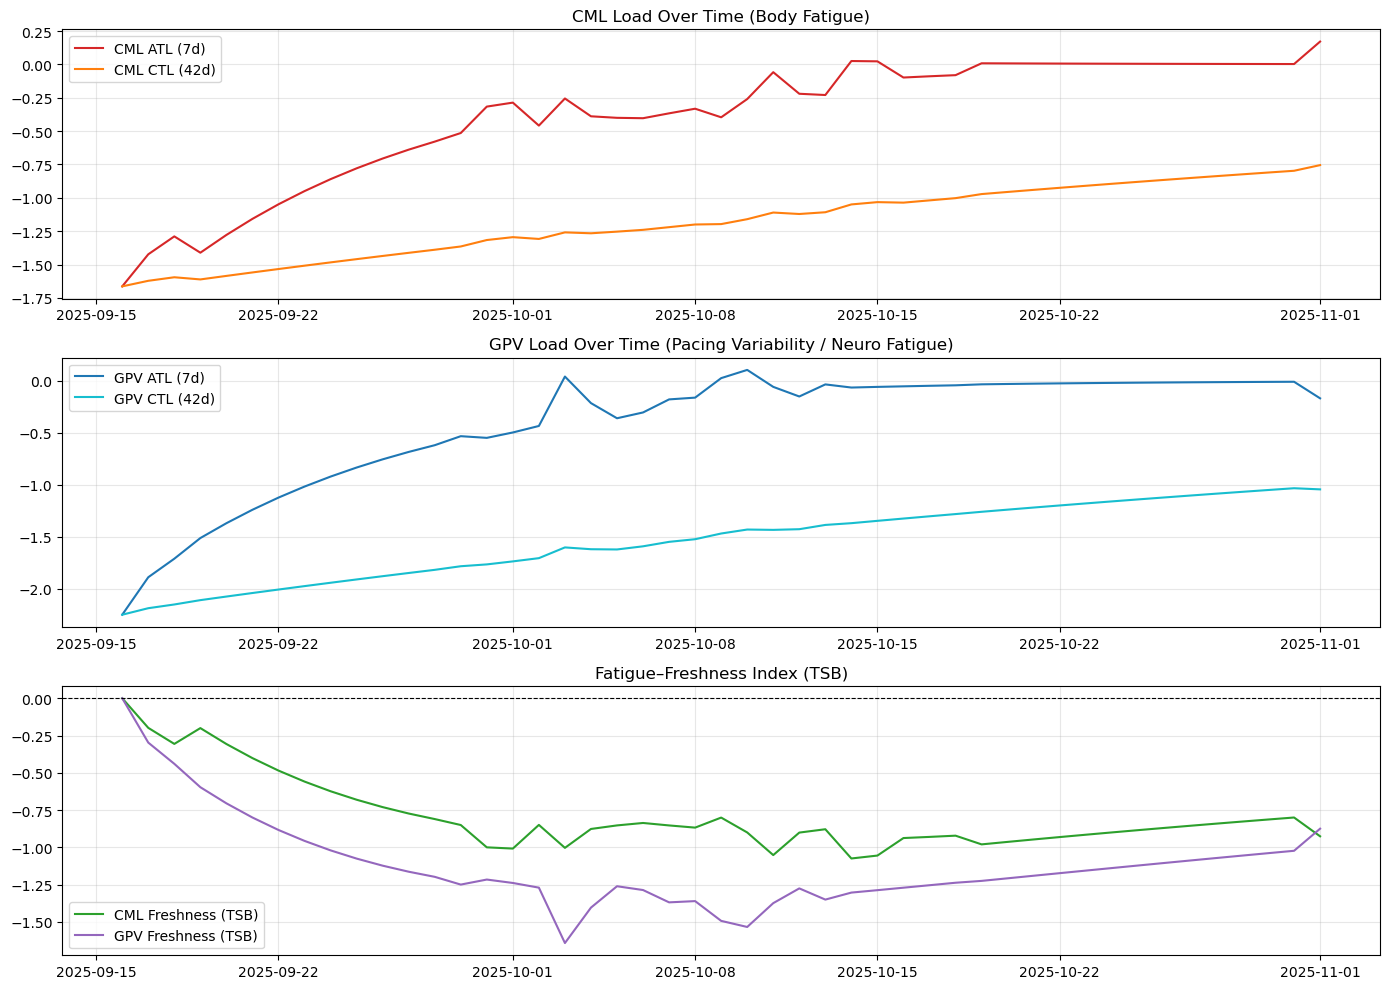

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# --- 1. CML Load (body load) ---
plt.subplot(3,1,1)
plt.plot(daily.index, daily["CML_ATL"], label="CML ATL (7d)", color="tab:red")
plt.plot(daily.index, daily["CML_CTL"], label="CML CTL (42d)", color="tab:orange")
plt.title("CML Load Over Time (Body Fatigue)")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 2. GPV Load (coordination/motor/mental fatigue) ---
plt.subplot(3,1,2)
plt.plot(daily.index, daily["GPV_ATL"], label="GPV ATL (7d)", color="tab:blue")
plt.plot(daily.index, daily["GPV_CTL"], label="GPV CTL (42d)", color="tab:cyan")
plt.title("GPV Load Over Time (Pacing Variability / Neuro Fatigue)")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 3. TSB (Freshness) ---
plt.subplot(3,1,3)
plt.plot(daily.index, daily["CML_TSB"], label="CML Freshness (TSB)", color="tab:green")
plt.plot(daily.index, daily["GPV_TSB"], label="GPV Freshness (TSB)", color="tab:purple")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Fatigue–Freshness Index (TSB)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 3.1 Saving classified runs to CSV


In [28]:
classified_df.to_csv("classified_runs_v1.csv", index=False)